<a href="https://colab.research.google.com/github/matti410/Trading-System-Pipeline-ML/blob/main/TS-Pipeline-ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q TA-Lib==0.8.1 backtesting==0.6.6   # versioni bloccate: cambiarle solo insieme al notebook di collaudo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.8/190.8 kB 4.8 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import sys
from pathlib import Path
from google.colab import userdata
import shutil
# Salva il token una volta in Colab: icona chiave a sinistra → "Secrets" → aggiungi GITHUB_TOKEN
# Assicurati che il nome del secret sia 'GITHUB_TOKEN' (o quello che preferisci) e non il token stesso.
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

REPO_DIR = Path('/content/Trading-System-Pipeline-ML')
if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)  # ripulisce il tentativo fallito precedente

!git clone https://{GITHUB_TOKEN}@github.com/matti410/Trading-System-Pipeline-ML.git

%cd Trading-System-Pipeline-ML

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Cloning into 'Trading-System-Pipeline-ML'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 34 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 2.42 MiB | 3.85 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/Trading-System-Pipeline-ML


In [ ]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import re
import sys
import time
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import datetime as dt
"""
from mt5_interaction import start_mt5, set_query_timeframe, retrieve_candlestick_data_range
import pytz
import MetaTrader5 as mt5
"""
import entry_long, entry_short
import engine as eng
from engine.indicatori import aggiungi_indicatori
import engine.event_study
import filter_conditions

print('import ok')

import ok


In [ ]:
"""
MT5_username='xxx'
MT5_password='xxx'
MT5_server='ICMarketsEU-Demo'
MT5_path=r"C:\Program Files\MetaTrader 5 IC Markets EU\terminal64.exe"

start_mt5(MT5_username, MT5_password, MT5_server, MT5_path)

start_time_utc = dt.datetime(2020, 1, 1, 23)
fmt = '%Y-%m-%d %H:%M:%S'
tz = pytz.timezone('Europe/Rome')
finish_time_utc = dt.datetime.now() + relativedelta(hours=4)

symbol = "EURUSD"
timeframe = 'M15'
horizon=15

df_raw = retrieve_candlestick_data_range(start_time_utc, finish_time_utc, symbol, timeframe=timeframe, dataframe=True).iloc[:-1]

df_raw.head(3)
"""
from engine.broker_tz_diagnostic import to_utc_index

symbol    = "EURUSD"
timeframe = 'M15'

df_raw = pd.read_csv(f'{symbol}_M15.csv', index_col='Date')
df_raw = to_utc_index(df_raw, "A_US_DST (NY+7h)", on_dst_gap="drop")

print(f"{symbol} {timeframe} — {len(df_raw):,} barre  ·  da {df_raw.index[0]}  a  {df_raw.index[-1]}")
df_raw.tail(3)

EURUSD M15 — 167,219 barre  ·  da 2020-01-01 22:00:00+00:00  a  2026-09-18 20:30:00+00:00


,Open,High,Low,Close,Volume,spread
Date,,,,,,
2026-09-18 20:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,0
2026-09-18 20:15:00+00:00,1.14876,1.14890,1.14868,1.14880,262,0
2026-09-18 20:30:00+00:00,1.14880,1.14885,1.14846,1.14857,182,0


### Features Engineering

In [ ]:
df = aggiungi_indicatori(df_raw)

In [ ]:
# CONDIZIONI DI INGRESSO LONG/SHORT
df = entry_short.aggiungi_trigger_short(df)
df = entry_long.aggiungi_trigger_long(df)

# CONDIZIONI DI FILTRO
for nome, (funzione, direction, pair) in filter_conditions.FILTRI.items():
    df[nome] = funzione(df)

df.dropna(inplace=True)
df.tail(5)

,Open,High,Low,Close,Volume,spread,rsi,macd,macd_signal,macd_hist,...,F8_UPTREND_CONTEXT,F9_DOWNTREND_CONTEXT,F10_TREND_CONVICTION_UP,F11_TREND_CONVICTION_DOWN,F12_EXTENDED_UP,F13_EXTENDED_DOWN,F16_PRICE_ABOVE_VWAP,F17_PRICE_BELOW_VWAP,F18_HIGH_NEAR_RANGE_TOP,F19_LOW_NEAR_RANGE_BOTTOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-18 19:30:00+00:00,1.14879,1.14885,1.14864,1.14867,402,0,65.639325,0.000440,0.000315,0.000125,...,True,False,True,False,True,False,True,False,True,False
2026-09-18 19:45:00+00:00,1.14867,1.14879,1.14857,1.14864,457,0,64.994395,0.000444,0.000341,0.000103,...,True,False,True,False,False,False,True,False,False,False
2026-09-18 20:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,0,66.415834,0.000452,0.000363,0.000089,...,True,False,True,False,False,False,True,False,True,False
2026-09-18 20:15:00+00:00,1.14876,1.14890,1.14868,1.14880,262,0,66.898341,0.000456,0.000382,0.000074,...,True,False,True,False,False,False,True,False,False,False
2026-09-18 20:30:00+00:00,1.14880,1.14885,1.14846,1.14857,182,0,61.432928,0.000436,0.000392,0.000043,...,True,False,True,False,False,False,True,False,False,False


### Andamento del prezzo dopo il trigger

##### IS - OOS Split

In [ ]:
df_is = df.iloc[:round(len(df)*0.8)]
df_oos = df.iloc[round(len(df)*0.8):]

In [ ]:
entry_long.registra_trigger_long()
entry_short.registra_trigger_short()

[registra_trigger_long] 26 entry long registrate (0 gia' presenti).
[registra_trigger_short] 26 entry short registrate (0 gia' presenti).


In [ ]:
H = 25
MIN_TRADES = 200

pip = 0.0001 unita' di prezzo  (prezzo medio 1.11)
4 entry scartate sotto min_trades=200
  barra   3/25
  barra   6/25
  barra   9/25
  barra  12/25
  barra  15/25
  barra  18/25
  barra  21/25
  barra  24/25
  barra  25/25

48 entry · orizzonte 25 barre · 177,440 trigger misurati
soglia di rumore per 48 entry × picco su 25 barre (famiglia 5%): |volte_incertezza| > 3.90  —  entry oltre: 0. Conta solo le prove di questa chiamata, e' un pavimento


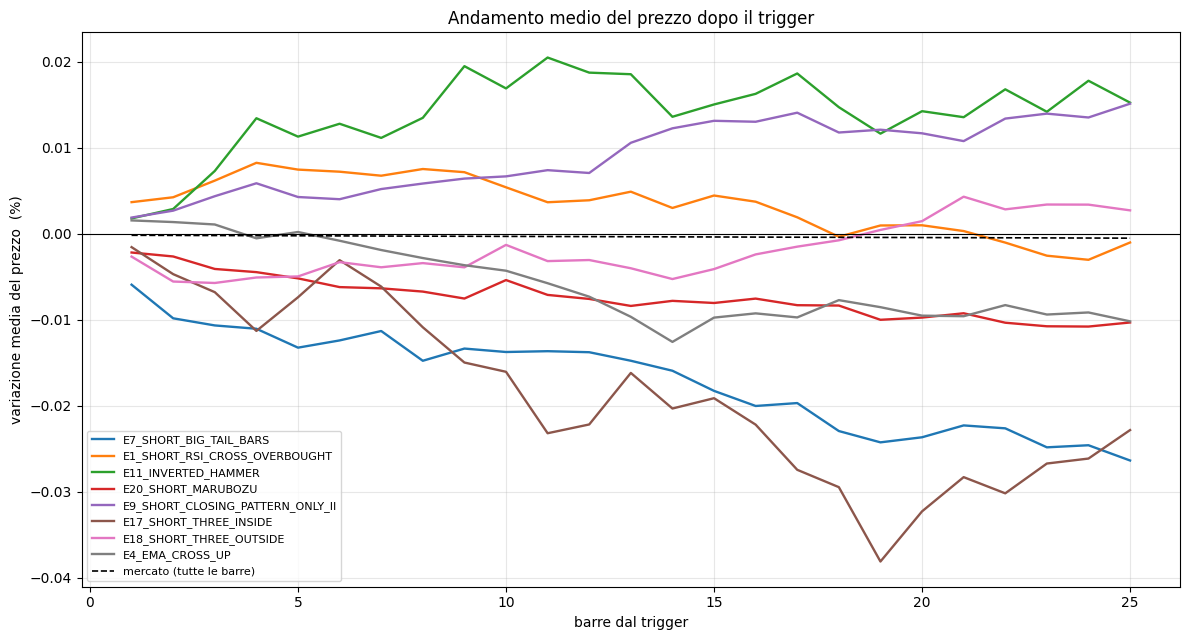

In [ ]:
entry_candidate = [n for n in eng.registry.list_entries()]
ev = eng.event_study.run_event_study(df_is, entry_names=entry_candidate, horizon=H, min_trades=MIN_TRADES)
ev.plot()

#### LONG side

In [ ]:
l1 = ev.sintesi[ev.sintesi['direction'] == 1][['candidato', 'picco_pips',
                                          'picco_pct', 'volte_incertezza',
                                          'oltre_rumore']].sort_values('picco_pips', ascending=False).head(6)
l1

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
2,E11_INVERTED_HAMMER,2.259293,0.020518,2.647491,False
12,E1_RSI_CROSS_OVERSOLD,1.632999,0.014801,1.881476,False
25,E7_BIG_TAIL_BARS,1.258023,0.011365,1.288552,False
26,E18_THREE_OUTSIDE,1.074672,0.009793,1.284835,False
30,E6_BACK_IN_STYLE,0.827157,0.007482,1.081583,False
38,E11_INVERTED_HAMMER_CONFIRMED,0.788157,0.007149,0.895098,False


In [ ]:
l2 = ev.sintesi[ev.sintesi['direction'] == -1][['candidato', 'picco_pips',
                                          'picco_pct', 'volte_incertezza',
                                          'oltre_rumore']].sort_values('picco_pips', ascending=True).head(6)
l2

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
5,E17_SHORT_THREE_INSIDE,-4.190923,-0.038099,-2.391037,False
0,E7_SHORT_BIG_TAIL_BARS,-2.910137,-0.026350,-2.880006,False
23,E16_SHORT_EVENING_STAR,-1.473027,-0.013368,-1.328178,False
18,E6_SHORT_BACK_IN_STYLE,-1.401637,-0.012671,-1.570267,False
3,E20_SHORT_MARUBOZU,-1.192770,-0.010771,-2.495678,False
44,E11_SHORT_SHOOTING_STAR_CONFIRMED,-1.138426,-0.010333,-0.721165,False


#### SHORT side

In [ ]:
s1 = ev.sintesi[ev.sintesi['direction'] == -1][['candidato', 'picco_pips',
                                           'picco_pct', 'volte_incertezza',
                                           'oltre_rumore']].sort_values('picco_pips', ascending=False).head(6)
s1

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
4,E9_SHORT_CLOSING_PATTERN_ONLY_II,1.676659,0.015150,2.480203,False
28,E4_SHORT_EMA_CROSS_DOWN,0.984461,0.008908,1.140366,False
1,E1_SHORT_RSI_CROSS_OVERBOUGHT,0.916683,0.008273,2.724314,False
11,E3_SHORT_INTRABAR_STRENGTH_FADE,0.426390,0.003853,1.966531,False
45,E10_SHORT_HANGING_MAN,0.338366,0.003051,0.702001,False
42,E13_SHORT_HARAMI,0.242505,0.002188,0.778840,False


In [ ]:
s2 = ev.sintesi[ev.sintesi['direction'] == 1][['candidato', 'picco_pips',
                                           'picco_pct', 'volte_incertezza',
                                           'oltre_rumore']].sort_values('picco_pips', ascending=True).head(6)

s2

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
20,E17_THREE_INSIDE,-1.936950,-0.017581,-1.475841,False
7,E4_EMA_CROSS_UP,-1.387682,-0.012556,-2.141847,False
47,E16_MORNING_STAR,-1.090798,-0.009933,-0.535074,False
8,E5_QUICK_PULLBACK,-0.989325,-0.008944,-2.105847,False
33,E14_HARAMI_CROSS_CONFIRMED,-0.806505,-0.007275,-1.026131,False
22,E13_HARAMI_CONFIRMED,-0.572180,-0.005163,-1.380629,False


### LONG Dataframe

In [ ]:
pattern = re.compile(r'^[F]\d+_')
colonne_eventi = [c for c in df.columns if pattern.match(c)]
colonne_ohlcv = ['Open', 'High', 'Low', 'Close', 'Volume']
entry_long_selected_feat  = l1.iloc[:2,0].to_list() + s1.iloc[:2,0].to_list()

df_LONG = df[colonne_ohlcv + entry_long_selected_feat + colonne_eventi]
df_LONG

,Open,High,Low,Close,Volume,E11_INVERTED_HAMMER,E1_RSI_CROSS_OVERSOLD,E9_SHORT_CLOSING_PATTERN_ONLY_II,E4_SHORT_EMA_CROSS_DOWN,F1_ADX_ABOVE,...,F8_UPTREND_CONTEXT,F9_DOWNTREND_CONTEXT,F10_TREND_CONVICTION_UP,F11_TREND_CONVICTION_DOWN,F12_EXTENDED_UP,F13_EXTENDED_DOWN,F16_PRICE_ABOVE_VWAP,F17_PRICE_BELOW_VWAP,F18_HIGH_NEAR_RANGE_TOP,F19_LOW_NEAR_RANGE_BOTTOM
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02 22:00:00+00:00,1.11717,1.11720,1.11688,1.11701,107,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
2020-01-02 22:15:00+00:00,1.11701,1.11713,1.11693,1.11712,62,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
2020-01-02 22:30:00+00:00,1.11712,1.11726,1.11708,1.11718,134,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
2020-01-02 22:45:00+00:00,1.11718,1.11718,1.11706,1.11712,64,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
2020-01-02 23:00:00+00:00,1.11712,1.11732,1.11712,1.11728,141,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-18 19:30:00+00:00,1.14879,1.14885,1.14864,1.14867,402,False,False,False,False,True,...,True,False,True,False,True,False,True,False,True,False
2026-09-18 19:45:00+00:00,1.14867,1.14879,1.14857,1.14864,457,False,False,False,False,True,...,True,False,True,False,False,False,True,False,False,False
2026-09-18 20:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,False,False,False,False,True,...,True,False,True,False,False,False,True,False,True,False


#### SHORT Dataframe

In [ ]:
pattern = re.compile(r'^[F]\d+_')
colonne_eventi = [c for c in df.columns if pattern.match(c)]
colonne_ohlcv = ['Open', 'High', 'Low', 'Close', 'Volume']
entry_short_selected_feat = l2.iloc[:2,0].to_list() + s2.iloc[:2,0].to_list()

df_SHORT = df[colonne_ohlcv + entry_short_selected_feat + colonne_eventi]
df_SHORT

,Open,High,Low,Close,Volume,E17_SHORT_THREE_INSIDE,E7_SHORT_BIG_TAIL_BARS,E17_THREE_INSIDE,E4_EMA_CROSS_UP,F1_ADX_ABOVE,...,F8_UPTREND_CONTEXT,F9_DOWNTREND_CONTEXT,F10_TREND_CONVICTION_UP,F11_TREND_CONVICTION_DOWN,F12_EXTENDED_UP,F13_EXTENDED_DOWN,F16_PRICE_ABOVE_VWAP,F17_PRICE_BELOW_VWAP,F18_HIGH_NEAR_RANGE_TOP,F19_LOW_NEAR_RANGE_BOTTOM
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02 22:00:00+00:00,1.11717,1.11720,1.11688,1.11701,107,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
2020-01-02 22:15:00+00:00,1.11701,1.11713,1.11693,1.11712,62,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
2020-01-02 22:30:00+00:00,1.11712,1.11726,1.11708,1.11718,134,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
2020-01-02 22:45:00+00:00,1.11718,1.11718,1.11706,1.11712,64,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
2020-01-02 23:00:00+00:00,1.11712,1.11732,1.11712,1.11728,141,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-18 19:30:00+00:00,1.14879,1.14885,1.14864,1.14867,402,False,False,False,False,True,...,True,False,True,False,True,False,True,False,True,False
2026-09-18 19:45:00+00:00,1.14867,1.14879,1.14857,1.14864,457,False,False,False,False,True,...,True,False,True,False,False,False,True,False,False,False
2026-09-18 20:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,False,False,False,False,True,...,True,False,True,False,False,False,True,False,True,False


In [ ]:
print("LONG:", df_LONG[entry_long_selected_feat].any(axis=1).sum())
print("SHORT:", df_SHORT[entry_short_selected_feat].any(axis=1).sum())

LONG: 6869
SHORT: 3454
